<a href="https://colab.research.google.com/github/kelvin-io/kelvin-io.github.io/blob/main/BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def run(history_price,ema_1,ema_2,test1,test2,info):
  usd=1000
  btc=0
  success={}

  for n in test1:
    for m in test2:
      for i in range(len(history_price)):
        if ema_1[i]>ema_2[i] and ema_1[i-1]<=ema_2[i-1] and ema_1[i-2]<=ema_2[i-2]:
          btc+=usd*n/history_price[i]
          usd*=1-n
          if info:
            print(usd+btc*history_price[i],i)
        elif ema_1[i]<ema_2[i] and ema_1[i-1]>=ema_2[i-1] and ema_1[i-2]>=ema_2[i-2]:
          usd+=btc*m*history_price[i]
          btc*=1-m
          if info:
            print(usd+btc*history_price[i],i)
      usd+=btc*history_price[i]
      btc=0
      success[(n,m)]=usd
      usd=1000
  return success

In [3]:
def calcu(name='BTC-USD',period='ytd',interval='1d',test1=[1.0],test2=[0.1],show=True,info=False):
  coin = yf.Ticker(name)
  history_data = coin.history(period=period,interval=interval)
  history_price = history_data['Close']
  ema12 = history_price.ewm(alpha=2/13).mean()
  ema26 = history_price.ewm(alpha=2/27).mean()
  if show:
    plt.plot(history_price, label="Close Prices")
    plt.plot(ema12, label="EMA12 Values")
    plt.plot(ema26, label="EMA26 Values")
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
  return run(history_price=history_price,ema_1=ema12,ema_2=ema26,test1=test1,test2=test2,info=info)

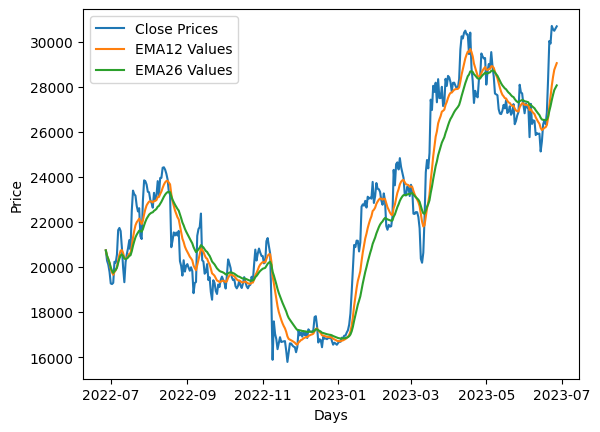

1000.0 1
1000.0000000000001 9
1030.0665297809976 54
1012.7386651575152 121
774.3253935345524 135
859.2328814047717 170
802.8932794504818 172
826.7263324529312 196
1078.313170929205 252
1162.520714875104 261
1319.0823296001317 316
1420.7443632178124 359
{(1.0, 0.1): 1451.4748696470772}


In [ ]:
for ttt in ['debug']:
  coin = yf.Ticker('BTC-USD')
  history_data = coin.history(period='1y',interval='1d')
  history_price = history_data['Close']
  ema12 = history_price.ewm(alpha=2/13).mean()
  ema26 = history_price.ewm(alpha=2/27).mean()
  if True:
    plt.plot(history_price, label="Close Prices")
    plt.plot(ema12, label="EMA12 Values")
    plt.plot(ema26, label="EMA26 Values")
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
  print(run(history_price=history_price,ema_1=ema12,ema_2=ema26,test1=[1.0],test2=[0.1],info=True))

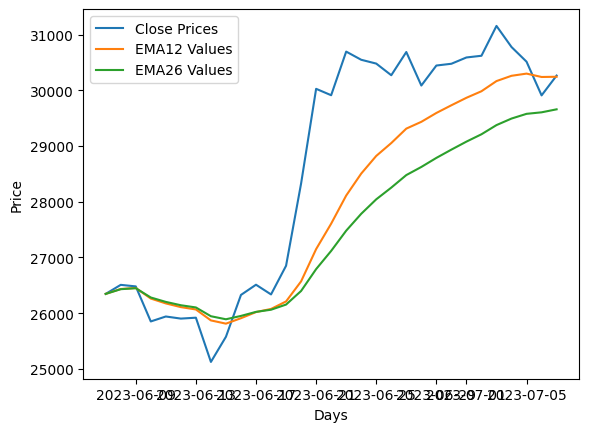

{(1.0, 0.1): 1149.1822133868222}


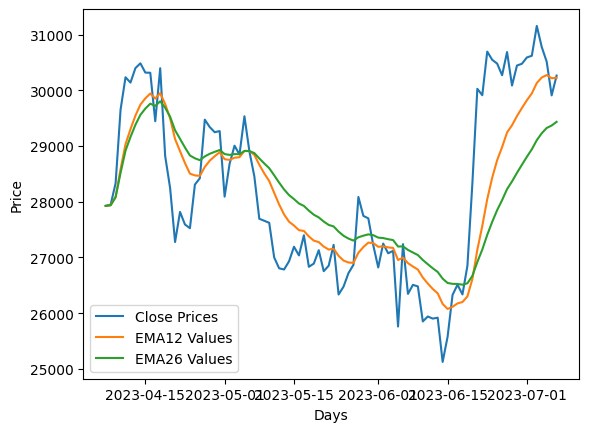

{(1.0, 0.1): 1019.3755711611617}


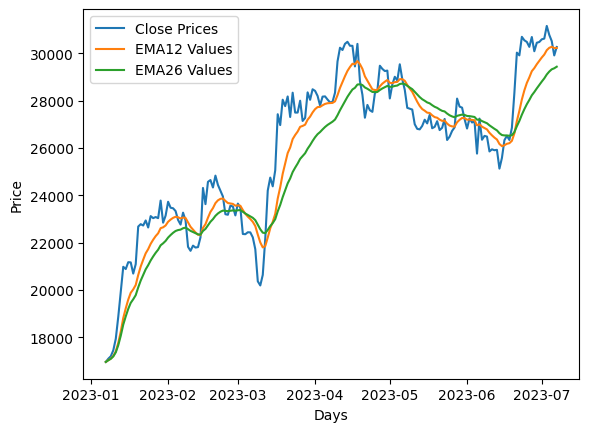

{(1.0, 0.1): 1225.005240991292}


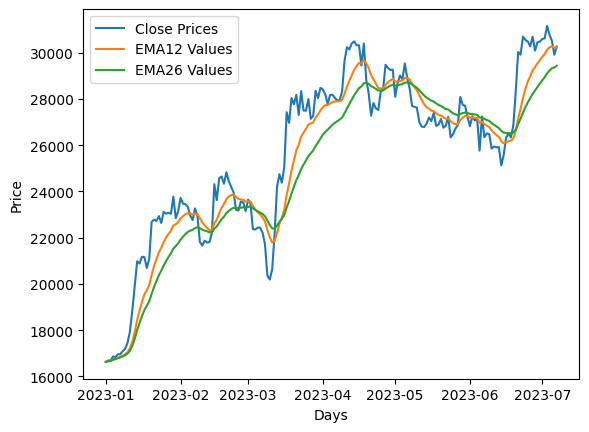

{(1.0, 0.1): 1231.802903111463}


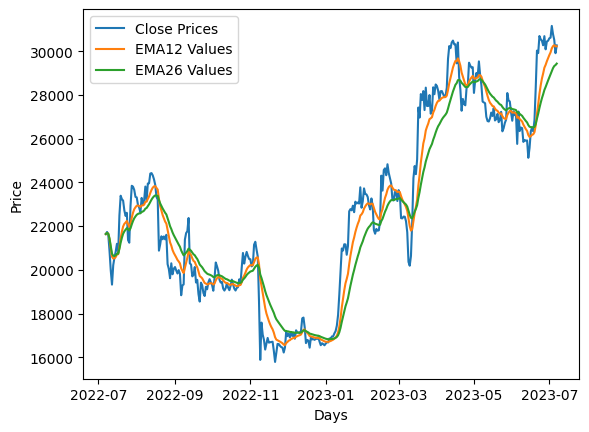

{(1.0, 0.1): 1308.610719696103}


In [4]:
period=['1mo','3mo','6mo','ytd','1y']
for i in period:
  success=calcu(period=i,test1=[1.0],test2=[0.1],show=True)
  print(success)